In [1]:
# importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("ggplot") #ggplot style for consistency

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# loading dataset
data_path = './data/constructions.csv';
df = pd.read_csv(data_path)

print("Dataset loaded successfully")
df.head(50)

Dataset loaded successfully


,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,25202.994687,244.843310,6602,76.300184,8,6.192198,52.988330,0,95.006343,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,49066.172542,263.123025,7121,63.527671,5,2.134473,50.885745,0,25.294824,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,48192.547163,608.985023,9956,47.099444,2,3.113728,93.905836,0,97.478830,Medium
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,2.946966e+07,4.970354e+06,809,974.565655,...,19811.151750,673.574344,3725,86.846394,5,4.070101,90.454316,1,95.098131,High
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2.329338e+06,5.793670e+05,354,347.990127,...,44866.565169,765.476122,4368,61.827163,6,2.759351,78.391069,0,43.624985,Low
5,PJT_6,Road,Seattle,2020-01-06,2020-09-18,16711072,2.368935e+07,6.978281e+06,255,379.859150,...,43142.511840,262.945324,4497,84.163241,6,2.351205,99.936163,0,98.459226,Low
6,PJT_7,Building,Los Angeles,2020-01-07,2021-11-25,47109273,4.746511e+07,3.558336e+05,792,831.587118,...,14480.617880,963.106378,9174,70.778731,7,1.523780,97.652604,0,13.225974,Low
7,PJT_8,Building,New York,2020-01-08,2021-09-19,42776934,5.903226e+07,1.625532e+07,842,794.863527,...,33093.068035,674.865331,6642,84.319723,3,8.857923,82.755449,0,69.467550,High
8,PJT_9,Building,Houston,2020-01-09,2021-03-17,25527188,3.143990e+07,5.912716e+06,579,751.477007,...,8270.704202,862.342227,9774,94.437374,0,3.600491,73.228728,0,33.953302,Medium
9,PJT_10,Dam,Los Angeles,2020-01-10,2021-05-23,5460276,6.213424e+06,7.531479e+05,250,314.304956,...,42651.982426,586.059144,5766,95.261771,5,3.612885,57.608536,0,21.651679,Medium


In [3]:
# Getting a high level overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Project_ID             1000 non-null   object 
 1   Project_Type           1000 non-null   object 
 2   Location               1000 non-null   object 
 3   Start_Date             1000 non-null   object 
 4   End_Date               1000 non-null   object 
 5   Planned_Cost           1000 non-null   int64  
 6   Actual_Cost            1000 non-null   float64
 7   Cost_Overrun           1000 non-null   float64
 8   Planned_Duration       1000 non-null   int64  
 9   Actual_Duration        1000 non-null   float64
 10  Schedule_Deviation     1000 non-null   float64
 11  Vibration_Level        1000 non-null   float64
 12  Crack_Width            1000 non-null   float64
 13  Load_Bearing_Capacity  1000 non-null   float64
 14  Temperature            1000 non-null   float64
 15  Humid

In [4]:
# Formatting & Standardization - We converted the date columns from string to datetime
df['Start_Date'] = pd.to_datetime(df['Start_Date'])
df['End_Date'] = pd.to_datetime(df['End_Date'])
print('Converted Start_Date and End_Date to datetime.')
print('Confirming date data types change:')
print(df.dtypes)

Converted Start_Date and End_Date to datetime.
Confirming date data types change:
Project_ID                       object
Project_Type                     object
Location                         object
Start_Date               datetime64[ns]
End_Date                 datetime64[ns]
Planned_Cost                      int64
Actual_Cost                     float64
Cost_Overrun                    float64
Planned_Duration                  int64
Actual_Duration                 float64
Schedule_Deviation              float64
Vibration_Level                 float64
Crack_Width                     float64
Load_Bearing_Capacity           float64
Temperature                     float64
Humidity                        float64
Weather_Condition                object
Air_Quality_Index                 int64
Energy_Consumption              float64
Material_Usage                  float64
Labor_Hours                       int64
Equipment_Utilization           float64
Accident_Count                    int6

In [5]:
# Descriptive statistics (mean, median, standard deviation,min, max, quartiles)
print(" Summary of the Statistics ")
print(df.describe().T)

 Summary of the Statistics 
                        count                 mean                  min  \
Start_Date               1000  2021-05-14 12:00:00  2020-01-01 00:00:00   
End_Date                 1000  2022-11-21 17:24:00  2020-09-01 00:00:00   
Planned_Cost           1000.0         26415087.626            1045475.0   
Actual_Cost            1000.0      31541079.260366       1180251.527639   
Cost_Overrun           1000.0       5125991.634366      -4648578.917822   
Planned_Duration       1000.0               538.62                180.0   
Actual_Duration        1000.0           645.560751           165.278211   
Schedule_Deviation     1000.0           106.940751           -79.136491   
Vibration_Level        1000.0             1.044378             0.107445   
Crack_Width            1000.0             2.456479             0.001205   
Load_Bearing_Capacity  1000.0           266.048158             50.10932   
Temperature            1000.0            17.114051            -9.997095 

Visualization of data distribution and relationships (histograms, scatter plots, correlation heatmaps, box plots, etc.)

Histograms diagram: Distribution of numeric features


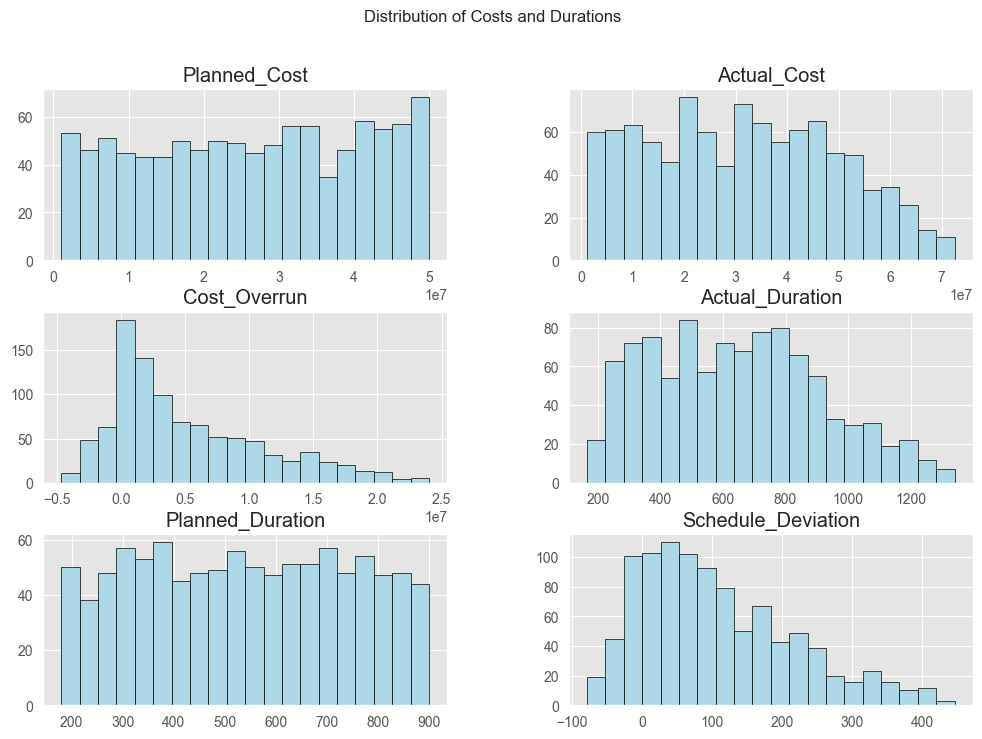


Scatter Plot diagram: Duration vs Cost Overrun


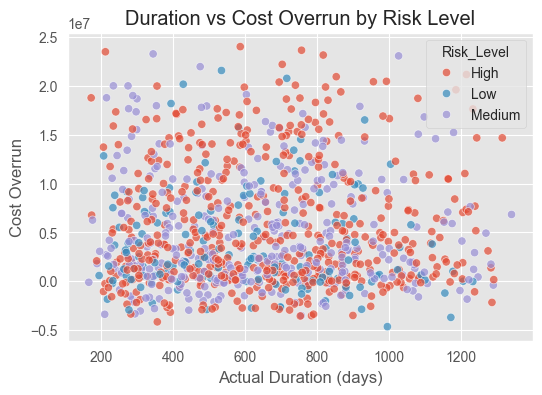


Correlation Heatmap diagram (numeric columns only)


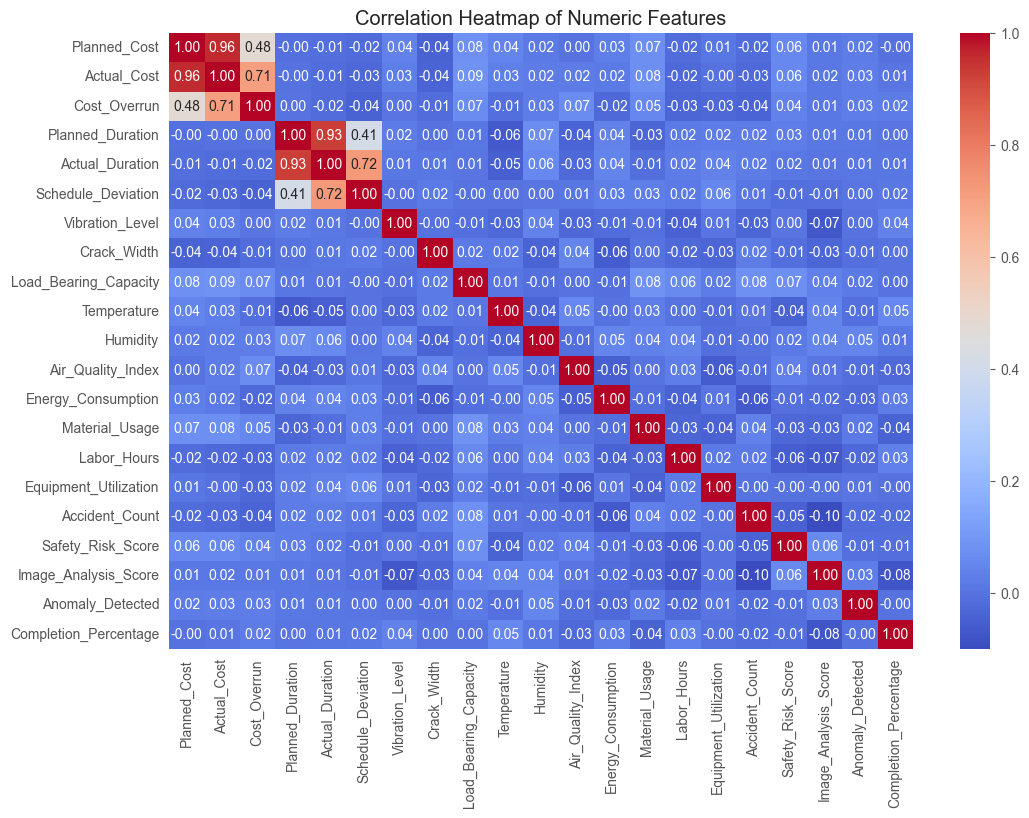


Boxplot diagram: Cost Overrun by Project Type


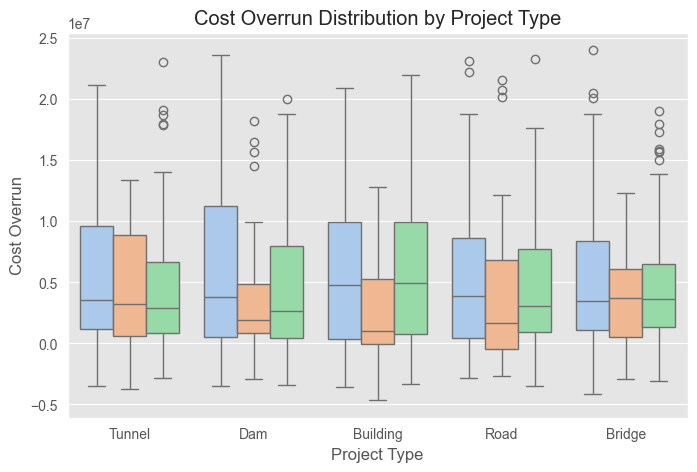

In [7]:
print("Visualization of data distribution and relationships (histograms, scatter plots, correlation heatmaps, box plots, etc.)")

# Histograms: Distribution of numeric features
print()
print("Histograms diagram: Distribution of numeric features")

df[['Planned_Cost','Actual_Cost','Cost_Overrun','Actual_Duration','Planned_Duration','Schedule_Deviation']].hist(
    bins=20, figsize=(12,8), color="lightblue", edgecolor="black"
)
plt.suptitle("Distribution of Costs and Durations")
plt.show()

# -------------------------------
# Scatter Plot: Duration vs Cost Overrun
print()
print("Scatter Plot diagram: Duration vs Cost Overrun")
plt.figure(figsize=(6,4))
sns.scatterplot(x="Actual_Duration", y="Cost_Overrun", hue="Risk_Level", data=df, alpha=0.7)
plt.title("Duration vs Cost Overrun by Risk Level")
plt.xlabel("Actual Duration (days)")
plt.ylabel("Cost Overrun")
plt.show()


# Correlation Heatmap (numeric columns only)
print()
print("Correlation Heatmap diagram (numeric columns only)")
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number])   # keep only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


# Boxplot: Cost Overrun by Project Type
print()
print("Boxplot diagram: Cost Overrun by Project Type")
plt.figure(figsize=(8,5))
sns.boxplot(x="Project_Type", y="Cost_Overrun", hue="Risk_Level",
            data=df, palette="pastel", legend=False)
plt.title("Cost Overrun Distribution by Project Type")
plt.xlabel("Project Type")
plt.ylabel("Cost Overrun")
plt.show()


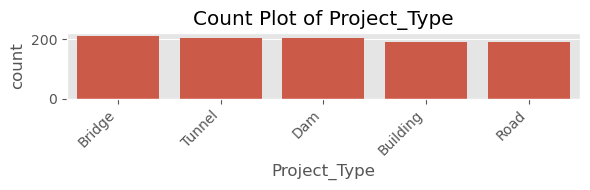

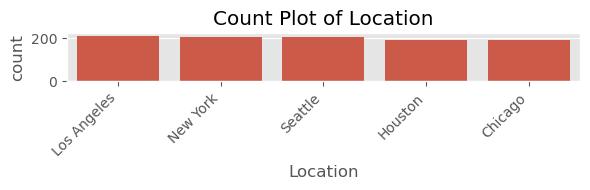

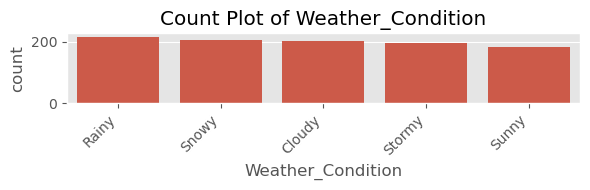

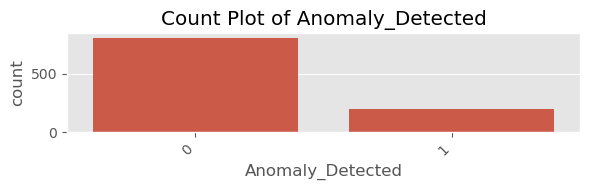

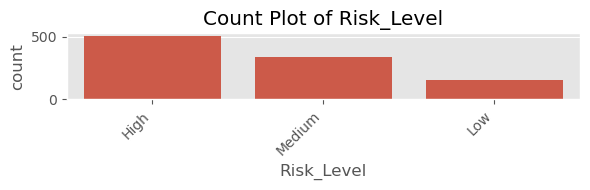

In [18]:
# Categorical Features Visualization

# List of categorical features
categorical_features = ['Project_Type', 'Location', 'Weather_Condition', 'Anomaly_Detected', 'Risk_Level']

for col in categorical_features:
    plt.figure(figsize=(6, 2))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [19]:
# Correlation
print("\n Correlation Matrix ")
df.select_dtypes(include='number').corr()


 Correlation Matrix 


,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,...,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage
Planned_Cost,1.000000,0.957756,0.479780,-0.004881,-0.012465,-0.021377,0.040609,-0.042537,0.079018,0.044909,...,0.000217,0.031970,0.073676,-0.015888,0.008281,-0.016465,0.057429,0.013798,0.022120,-0.002922
Actual_Cost,0.957756,1.000000,0.711835,-0.003282,-0.014916,-0.030317,0.033771,-0.038504,0.085281,0.032312,...,0.022000,0.017864,0.076745,-0.023601,-0.002466,-0.025117,0.058589,0.015750,0.026129,0.005625
Cost_Overrun,0.479780,0.711835,1.000000,0.001905,-0.015062,-0.040288,0.003856,-0.013586,0.067201,-0.011097,...,0.066589,-0.023577,0.054209,-0.033200,-0.027748,-0.036419,0.038492,0.014355,0.025696,0.024296
Planned_Duration,-0.004881,-0.003282,0.001905,1.000000,0.927587,0.410781,0.021574,0.003095,0.010443,-0.064289,...,-0.038881,0.039948,-0.032267,0.019809,0.021088,0.023944,0.026181,0.013361,0.013662,0.003767
Actual_Duration,-0.012465,-0.014916,-0.015062,0.927587,1.000000,0.721667,0.014641,0.009325,0.007821,-0.048782,...,-0.026217,0.044016,-0.011505,0.022832,0.038566,0.022337,0.015545,0.007052,0.011991,0.009343
Schedule_Deviation,-0.021377,-0.030317,-0.040288,0.410781,0.721667,1.000000,-0.004244,0.017022,-0.000263,0.000074,...,0.008062,0.033396,0.031708,0.019014,0.055042,0.010144,-0.010573,-0.007547,0.003948,0.015821
Vibration_Level,0.040609,0.033771,0.003856,0.021574,0.014641,-0.004244,1.000000,-0.003285,-0.008672,-0.026866,...,-0.029668,-0.014336,-0.005605,-0.044057,0.006608,-0.033769,0.003776,-0.072938,0.002425,0.038261
Crack_Width,-0.042537,-0.038504,-0.013586,0.003095,0.009325,0.017022,-0.003285,1.000000,0.018472,0.018126,...,0.044308,-0.057755,0.003015,-0.024824,-0.031694,0.022881,-0.009256,-0.033415,-0.007461,0.003271
Load_Bearing_Capacity,0.079018,0.085281,0.067201,0.010443,0.007821,-0.000263,-0.008672,0.018472,1.000000,0.005281,...,0.002075,-0.008152,0.082110,0.063809,0.021564,0.079129,0.074136,0.035576,0.018651,0.000915
Temperature,0.044909,0.032312,-0.011097,-0.064289,-0.048782,0.000074,-0.026866,0.018126,0.005281,1.000000,...,0.051323,-0.004744,0.025484,0.001327,-0.014682,0.006375,-0.041935,0.044725,-0.005168,0.051957


In [20]:
# Feature Enginering

# We created a copy of the original dataframe for our modeling
df_model = df.copy()

In [21]:
def engineer_features(df):

    # -----------------------------
    # 1. DATE FEATURES
    # -----------------------------
    df['Start_Year'] = df['Start_Date'].dt.year
    df['Start_Month'] = df['Start_Date'].dt.month
    df['Start_Week'] = df['Start_Date'].dt.isocalendar().week.astype(int)
    df['Start_DayOfWeek'] = df['Start_Date'].dt.dayofweek

    # Season extraction
    def get_season(m):
        if m in [12, 1, 2]: return 'Winter'
        elif m in [3, 4, 5]: return 'Spring'
        elif m in [6, 7, 8]: return 'Summer'
        else: return 'Fall'

    df['Season'] = df['Start_Month'].apply(get_season)

    # Duration difference
    df['Duration_Diff'] = df['Actual_Duration'] - df['Planned_Duration']


    # -----------------------------
    # 2. COST FEATURES
    # -----------------------------
    df['Cost_Overrun_Percentage'] = np.where(
        df['Planned_Cost'] != 0,
        (df['Actual_Cost'] - df['Planned_Cost']) / df['Planned_Cost'] * 100,
        0
    )

    df['Cost_Per_Day'] = np.where(
        df['Actual_Duration'] != 0,
        df['Actual_Cost'] / df['Actual_Duration'],
        0
    )


    # -----------------------------
    # 3. SCHEDULE FEATURES
    # -----------------------------
    df['Duration_Ratio'] = np.where(
        df['Planned_Duration'] != 0,
        df['Actual_Duration'] / df['Planned_Duration'],
        1
    )

    df['Behind_Schedule'] = (df['Duration_Ratio'] > df['Completion_Percentage']/100).astype(int)


    # -----------------------------
    # 4. SAFETY FEATURES
    # -----------------------------
    df['Safety_Index'] = np.where(
        df['Labor_Hours'] != 0,
        df['Accident_Count'] / df['Labor_Hours'],
        0
    )


    # -----------------------------
    # 6. PROGRESS FEATURES
    # -----------------------------
    df['Completion_Gap'] = 100 - df['Completion_Percentage']

    df['Progress_Efficiency'] = np.where(
        df['Actual_Duration'] != 0,
        df['Completion_Percentage'] / (df['Actual_Duration'] / df['Planned_Duration']),
        0
    )


    # -----------------------------
    # 7. STRUCTURAL FEATURES
    # -----------------------------
    # Normalize using percentile ranks
    df['Vibration_norm'] = df['Vibration_Level'].rank(pct=True)
    df['Crack_norm'] = df['Crack_Width'].rank(pct=True)
    df['Load_norm'] = df['Load_Bearing_Capacity'].rank(pct=True)

    df['Structural_Risk'] = df['Vibration_norm'] + df['Crack_norm'] - df['Load_norm']

    # -----------------------------
    # 7. Energy Intensity
    # -----------------------------
    # Calculate Energy Intensity
    df["Energy_Intensity"] = df["Energy_Consumption"] / df["Actual_Duration"].replace(0, np.nan)
    
    # Optional: handle NaN values after division
    df["Energy_Intensity"] = df["Energy_Intensity"].fillna(0)

    # -----------------------------
    # 8. ANOMALY FEATURES
    # -----------------------------
    df['Anomaly_Flag'] = df['Anomaly_Detected'].astype(int)


    # -----------------------------
    # 9. WEATHER FEATURES
    # -----------------------------
    df['Weather_Severity'] = (
        df['Air_Quality_Index'] * 0.4 +
        df['Humidity'] * 0.3 +
        df['Temperature'] * 0.3
    )


    # -----------------------------
    # 10. CATEGORICAL ENCODING
    # -----------------------------
    # One-hot encode Project_Type & Season
    df = pd.get_dummies(df, columns=['Project_Type', 'Season'], drop_first=True)

    # Ordinal Encode Risk_Level
    risk_map = {"Low": 0, "Medium": 1, "High": 2}
    df['Risk_Category_Encoded'] = df['Risk_Level'].map(risk_map)

    # One-hot Encode Weather_Condition
    df = pd.get_dummies(df, columns=['Weather_Condition'], drop_first=True)

    # One-hot Encode for Location
    df = pd.get_dummies(df, columns=['Location'], drop_first=True)


    # -----------------------------
    # 11. DROP UNNEEDED COLUMNS
    # -----------------------------
    to_drop = [
        'Project_ID',
        'Risk_Level',
        'Start_Date',
        'End_Date',
        'Vibration_norm',
        'Crack_norm',
        'Load_norm'
    ]

    df = df.drop(columns=[col for col in to_drop if col in df.columns])

    return df


In [22]:
new_df = engineer_features(df_model)
new_df.head()

,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,...,Season_Winter,Risk_Category_Encoded,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Stormy,Weather_Condition_Sunny,Location_Houston,Location_Los Angeles,Location_New York,Location_Seattle
0,12260784,1.505450e+07,2.793720e+06,699,813.914852,114.914852,1.534172,2.809385,471.197381,18.541555,...,True,2,False,True,False,False,True,False,False,False
1,2369277,3.507054e+06,1.137777e+06,269,384.118221,115.118221,0.687979,3.704416,355.155126,23.316772,...,True,0,False,True,False,False,True,False,False,False
2,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,182.777915,0.951146,3.309302,236.493416,42.957877,...,True,1,False,False,False,False,True,False,False,False
3,24499306,2.946966e+07,4.970354e+06,809,974.565655,165.565655,0.870396,1.777649,360.290394,22.420894,...,True,2,False,False,False,False,True,False,False,False
4,1749971,2.329338e+06,5.793670e+05,354,347.990127,-6.009873,1.969770,4.044293,204.790836,15.914491,...,True,0,False,False,False,False,False,False,False,True
